# Data 6550: Reproducibility in Data Science : A Data Ethic Project
## Wine feature importance and quality prediction: A comparative study of machine learning algorithms with unbalanced data
- Siphendulwe Zaza1zazasiphendulwe@gmail.com 
- Marcellin Atemkeng1∗m.atemkeng@ru.ac.za Sisipho 
- Hamlomo1,2s.hamlomo@ru.ac.za

Citation
- Zaza, S., Marcellin Atemkeng, & Sisipho Hamlomo. (2023). Wine feature importance and quality prediction: A comparative study of
  machine learning algorithms with unbalanced data. ArXiv (Cornell University). https://doi.org/10.48550/arxiv.2310.01584



### Group 5

#### ReadMe
- This notebook created by Alexander Price for Data6550 Ethics at MTSU. 
- In this notebook use of AI was used to debug, get suggestiosn, and help make some code blocks. Claude AI, Githup Copliot were used.
- A lot of this code is from resued homework done by myself in other classes at MTSU.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
red_wine_raw = pd.read_csv("D:\\Data Ethics\\Ethics Group 5 Project 5 Wine\\winequality-red.csv",header=0, sep=";")

In [4]:
red_wine_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
red_wine_raw['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

## Pre Processing 

In [6]:
red_wine = red_wine_raw.copy()

In [7]:
red_wine['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

### Excluding duplicate entries and data points with missing values from all wine category dataframes

In [8]:
red_wine.duplicated().sum()

240

In [9]:
red_wine.drop_duplicates(inplace=True)

In [10]:
red_wine.dropna(inplace=True)

In [11]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 138.0 KB


In [12]:
red_wine['quality'].value_counts()

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

- After dropping duplicates and missing values new values in each dataframe are 
    - quality of 5: went from 681 to 577 dropping a total of 104 duplicates and no values
    - quality of 6 : went from 638 to 535 dropping a total of 103 duplicates and no values
    - quality of 7 : went from 199 to 167 dropping a total of 32 duplicates and no values
    - quality of 4 : none was dropped
    - quality of 8 : none was dropped
    - quality of 3 : none was dropped

#### Encoding Quality 
- bad wine is quality less than 5
- normal wine is quality between 5 and 6 
- good wine is quality between 7 and 10

- so for encoding:
    - 0 = bad wine
    - 1 = normal wine
    - 2 = good wine

In [13]:
def encode_quality(quality):
    if quality < 5:
        return 0  # bad wine
    elif 5 <= quality <= 6:
        return 1  # normal wine
    elif 7 <= quality <= 10:
        return 2  # good wine
    else:
        return np.nan

red_wine_encoded = red_wine['quality'].apply(encode_quality)

In [14]:
red_wine_processed = red_wine.copy()
red_wine_processed['quality'] = red_wine_encoded

In [15]:
red_wine_processed['quality'].sample(10)

1501    1
850     1
598     1
858     2
456     1
145     1
737     1
713     1
840     2
1572    1
Name: quality, dtype: int64

In [16]:
red_wine_processed['quality'].value_counts()

quality
1    1112
2     184
0      63
Name: count, dtype: int64

## Analysis before pre processing

### Correlation Matrix

- So they used the entire dataset for this correlation matrix and the paper does not specify that they did this before or after preprocessing. So to see the differences I did a a correlation with the raw data and then make another after the preprocessing, the one in the paper is one that is done before pre processing and matches exactly.

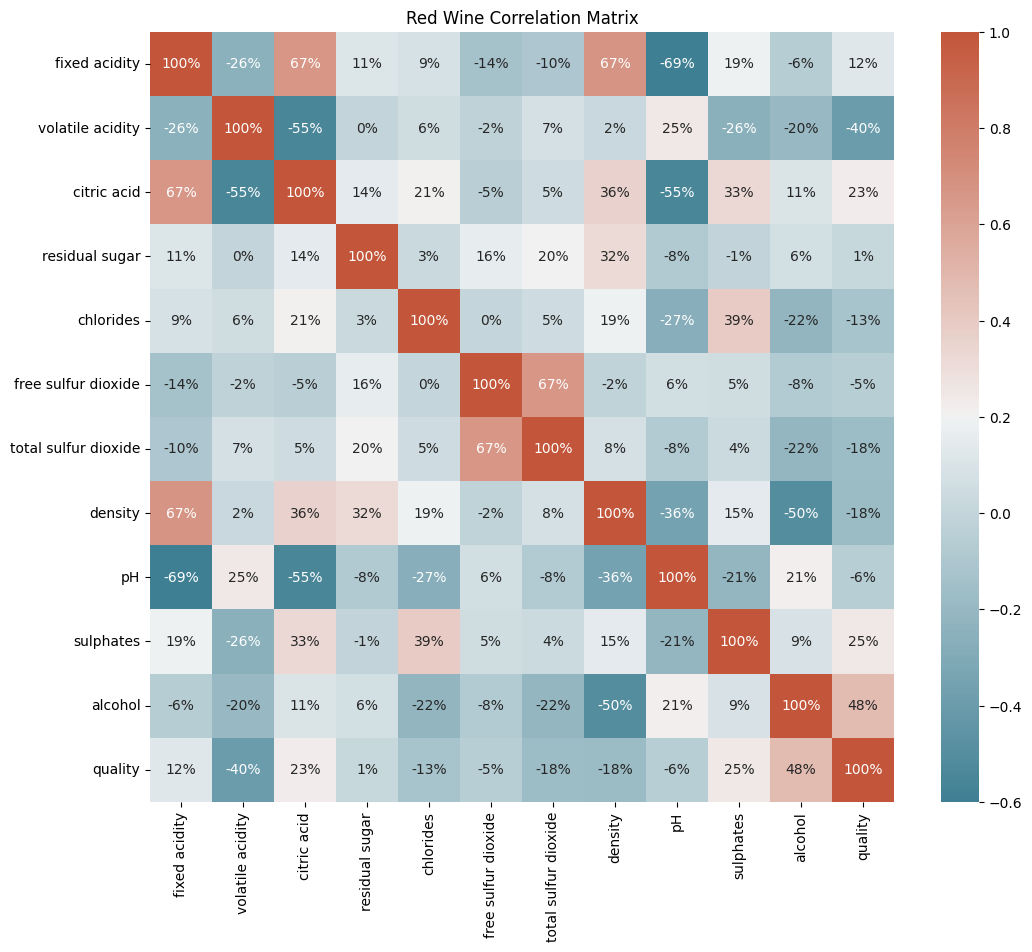

In [17]:
# Before preprocessing just doing a initial data exploration 
correlation_matrix = red_wine.corr()
percent_labels = correlation_matrix.multiply(100).round().astype(int).astype(str) + '%' # To match the paper's correlation matrix with percentage labels
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=percent_labels, fmt='',
            cmap= sns.diverging_palette(220, 20, as_cmap=True), vmin=-0.6, vmax=1) # Adjusted vmin and vmax for better color contrast and readability to reproduce the paper
plt.title('Red Wine Correlation Matrix')
plt.show()

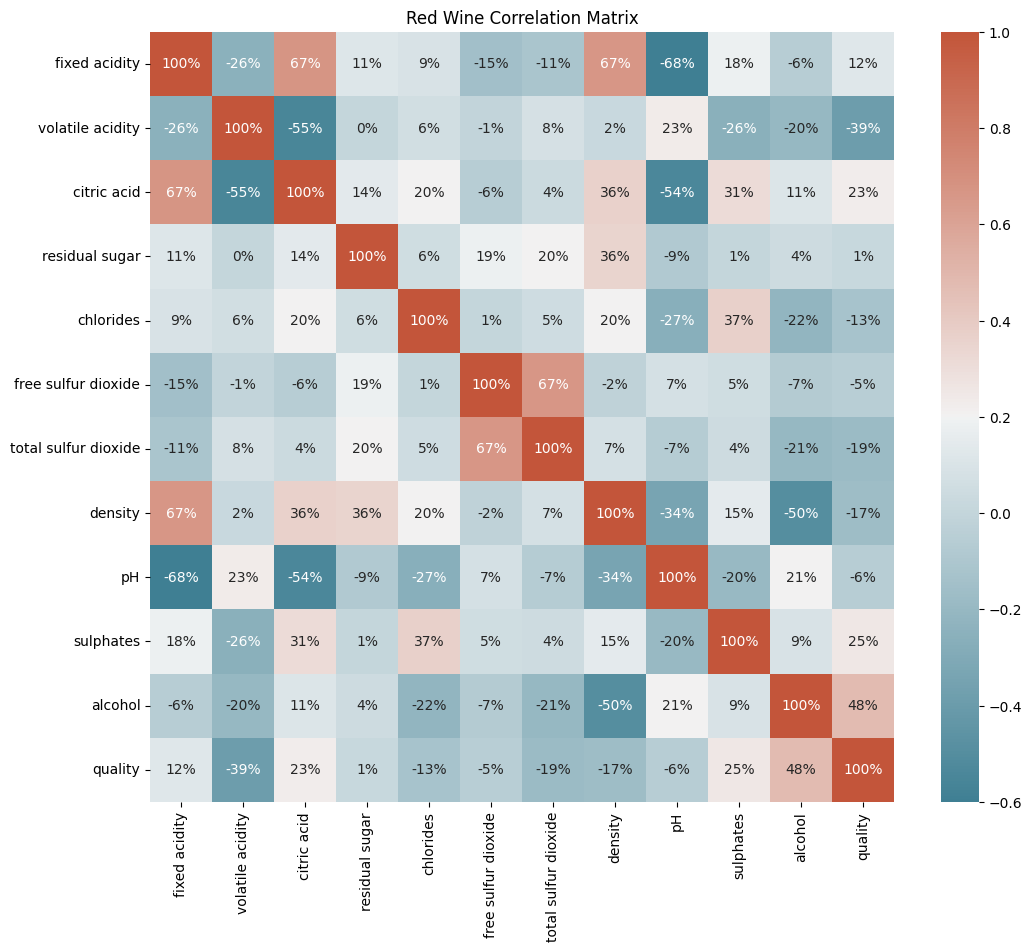

In [18]:
## After preprocessing 
correlation_matrix = red_wine_raw.corr()
percent_labels = correlation_matrix.multiply(100).round().astype(int).astype(str) + '%'
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=percent_labels, fmt='',
            cmap= sns.diverging_palette(220, 20, as_cmap=True), vmin=-0.6, vmax=1)
plt.title('Red Wine Correlation Matrix')
plt.show()


In [19]:
X = red_wine.drop('quality', axis=1)
y = red_wine['quality']

In [20]:
# Ranked table of correlations with quality sorted by percentage of correlation.
corr_pct = (X.corrwith(y) * 100).round().astype(int)
corr_ranked = corr_pct.reindex(corr_pct.abs().sort_values(ascending=False).index)

correlation_table = corr_ranked.rename_axis('Name').reset_index(name='Correlation')
correlation_table.insert(0, 'Rank', range(1, len(correlation_table) + 1))
correlation_table['Correlation'] = correlation_table['Correlation'].astype(str) + '%'

correlation_table.style.hide(axis='index')

Rank,Name,Correlation
1,alcohol,48%
2,volatile acidity,-40%
3,sulphates,25%
4,citric acid,23%
5,total sulfur dioxide,-18%
6,density,-18%
7,chlorides,-13%
8,fixed acidity,12%
9,pH,-6%
10,free sulfur dioxide,-5%


### Corelation Heatmap analysis and comparisons
- So from corelation table and the table from it is one to one exact how it is
- it was challenging in finding out how to do it and had to have help with claude in understanding of how the paper was saying how they encoded quality and the correlation heatmap is before encoding and had to try mulitple times to get it exact. The procedure of following the paper is not in order and that is one of the challenges I am facing. 

- with dropping the duplicates and no values has influence on correlation with changing some correlations with 1% difference with the raw and preprocessed dataframes. 

### Bar Charts 
- Residual sugar vs quality
- Alcohol vs quality
Using the raw data as nothing has been noted on using the preprocessed data

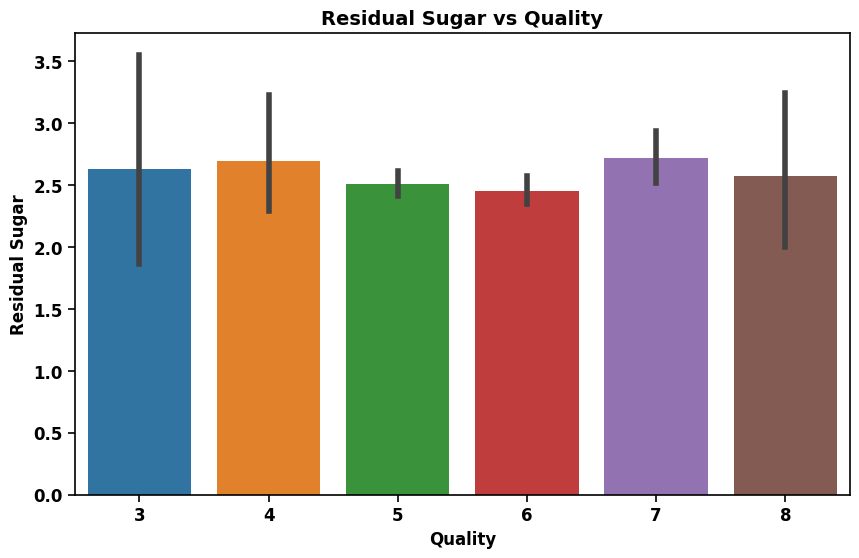

In [21]:
plt.figure(figsize=(10,6))
ax = sns.barplot(y='residual sugar', x='quality', data=red_wine, palette='tab10', err_kws={'linewidth': 4.0})
ax.grid(False)
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
for spine in ax.spines.values(): spine.set_visible(True),spine.set_linewidth(1.2),spine.set_color('black')
ax.tick_params(axis='x', which='major', bottom=True, top=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
ax.tick_params(axis='y', which='major', left=True, right=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
plt.ylabel('Residual Sugar', fontsize=12, fontweight='bold')
plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.title('Residual Sugar vs Quality', fontsize=14, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.show()

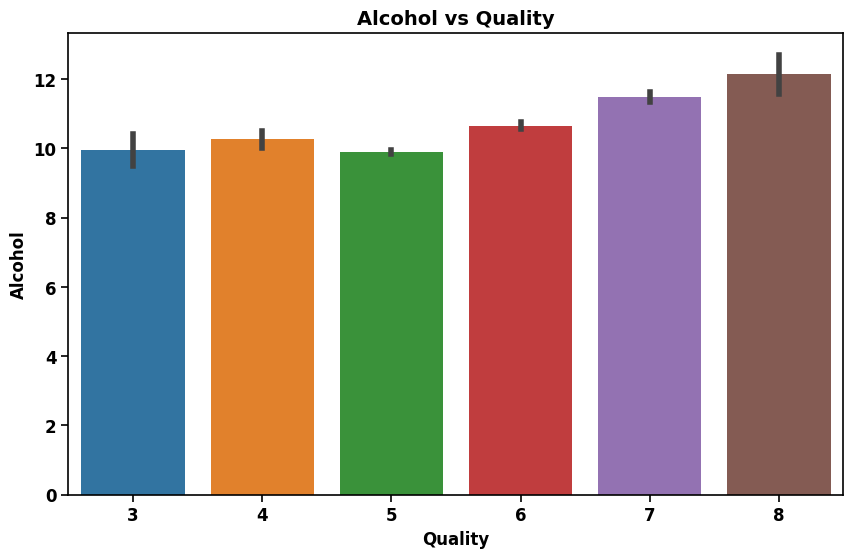

In [22]:
plt.figure(figsize=(10,6))
ax = sns.barplot(y='alcohol', x='quality', data=red_wine, palette='tab10', err_kws={'linewidth': 4.0})
ax.grid(False)
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
for spine in ax.spines.values(): spine.set_visible(True),spine.set_linewidth(1.2),spine.set_color('black')
ax.tick_params(axis='x', which='major', bottom=True, top=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
ax.tick_params(axis='y', which='major', left=True, right=False, length=5, width=1.2, direction='out', color='black', labelcolor='black')
plt.ylabel('Alcohol', fontsize=12, fontweight='bold')
plt.xlabel('Quality', fontsize=12, fontweight='bold')
plt.title('Alcohol vs Quality', fontsize=14, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.show()

- The bar plots can be reproduced exactly as the paper shows, however I knew from the correlation index they are using the raw data not the preprocessed data. 
- This also shows why they dropped residual sugar with it having very very little correlation with quality across all the wines. 

#### Dropping Residual Sugar 

In [23]:
# Rebuild processed data with encoded quality and without residual sugar.
red_wine_processed= red_wine.drop(columns=['residual sugar']).copy()
red_wine_processed['quality'] = red_wine_encoded

In [24]:
red_wine_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   chlorides             1359 non-null   float64
 4   free sulfur dioxide   1359 non-null   float64
 5   total sulfur dioxide  1359 non-null   float64
 6   density               1359 non-null   float64
 7   pH                    1359 non-null   float64
 8   sulphates             1359 non-null   float64
 9   alcohol               1359 non-null   float64
 10  quality               1359 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 127.4 KB


## Classification Methods
- With no code available and in the paper they explain it mathematically I am going to just use basic modeling but if given that they normalized the data 

### No train test split
- Before going in the paper there is not test train split noted and with no code as well to show that they did that I am going to to make my own test train split for the modeling which should have happened with labeling X and y, with doing a 80% training and 20% test sets. 
- To have a better modeling I am using the pre processed data with the label encoded quality and the duplicates and no value removed.

### Importing Libraries 
- unknown what libraries used in the paper added to do the modeling and evaluation to try to reproduce the results from the paper.

In [25]:
from sklearn.svm import LinearSVR, SVR, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_blobs
from sklearn.model_selection import cross_val_score, RepeatedKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score


In [26]:
___# pip install imbalanced-learn had to install new libaries to do SMOTE
from imblearn.over_sampling import SMOTE

In [27]:
from sklearn.model_selection import train_test_split
y = red_wine_processed['quality']
X = red_wine_processed.drop(columns=['quality'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [29]:
# Alias scaled data with _svm suffix to keep SVM variables separate from other models
X_train_svm, X_test_svm, y_train_svm, y_test_svm = X_train_scaled, X_test_scaled, y_train, y_test

In [30]:
# Apply SMOTE once to the training split so each model is trained on all three encoded classes.
smote = SMOTE(random_state=42, k_neighbors=2)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

### Support Vector Machine

In [31]:
svm_model = SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced', random_state=42)
svm_model.fit(X_train_balanced, y_train_balanced)
y_pred_svm = svm_model.predict(X_test_svm)
y_pred_svm

array([1, 1, 1, 1, 1, 0, 2, 0, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1,
       1, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       2, 1, 2, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0, 2, 2, 1, 1,
       1, 2, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 0, 2, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 2, 1, 2], dtype=int64)

In [32]:
svm_acc_train = svm_model.score(X_train_svm, y_train_svm)
svm_acc_test = svm_model.score(X_test_svm, y_test_svm)
print(f"SVM Accuracy on Training Set: {svm_acc_train:.4f}")
print(f"SVM Accuracy on Test Set: {svm_acc_test:.4f}")

SVM Accuracy on Training Set: 0.8583
SVM Accuracy on Test Set: 0.7794


In [33]:
# Weighted summary metrics for multiclass SVM.
svm_precision_weighted = precision_score(y_test_svm, y_pred_svm, average='weighted', zero_division=0)
svm_recall_weighted = recall_score(y_test_svm, y_pred_svm, average='weighted', zero_division=0)
svm_f1_weighted = f1_score(y_test_svm, y_pred_svm, average='weighted', zero_division=0)
print(f"SVM Precision (weighted): {svm_precision_weighted:.4f}")
print(f"SVM Recall (weighted): {svm_recall_weighted:.4f}")
print(f"SVM F1 Score (weighted): {svm_f1_weighted:.4f}")

SVM Precision (weighted): 0.8376
SVM Recall (weighted): 0.7794
SVM F1 Score (weighted): 0.7996


In [34]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1_vals, _ = precision_recall_fscore_support(
    y_test_svm, y_pred_svm, labels=[0, 1, 2], zero_division=0
)

class_metrics = {
    0: {'precision': prec[0], 'recall': rec[0], 'f1': f1_vals[0]},
    1: {'precision': prec[1], 'recall': rec[1], 'f1': f1_vals[1]},
    2: {'precision': prec[2], 'recall': rec[2], 'f1': f1_vals[2]},
}
class_metrics

{0: {'precision': 0.27586206896551724,
  'recall': 0.6153846153846154,
  'f1': 0.38095238095238093},
 1: {'precision': 0.921875,
  'recall': 0.7972972972972973,
  'f1': 0.855072463768116},
 2: {'precision': 0.5294117647058824,
  'recall': 0.7297297297297297,
  'f1': 0.6136363636363636}}

In [35]:
# Save baseline SVM predictions for the comparison table.
model_predictions = {'SVM': y_pred_svm}

print(f"SVM Accuracy: {svm_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics[cls]['precision']:.4f}, "
        f"Recall: {class_metrics[cls]['recall']:.4f}, "
        f"F1: {class_metrics[cls]['f1']:.4f}"
    )

SVM Accuracy: 0.7794
Class 0 -> Precision: 0.2759, Recall: 0.6154, F1: 0.3810
Class 1 -> Precision: 0.9219, Recall: 0.7973, F1: 0.8551
Class 2 -> Precision: 0.5294, Recall: 0.7297, F1: 0.6136


In [36]:
from sklearn.metrics import classification_report, accuracy_score

def _coerce_to_class_labels(y_pred, class_labels):
    y_pred = np.asarray(y_pred)
    if np.issubdtype(y_pred.dtype, np.floating):
        label_array = np.asarray(class_labels, dtype=float)
        nearest_idx = np.abs(y_pred.reshape(-1, 1) - label_array.reshape(1, -1)).argmin(axis=1)
        return label_array[nearest_idx].astype(int)
    return y_pred

def _canonical_prediction_key(name):
    key = str(name).strip().lower()

    # Support keys like y_pred_rf and rf_y_pred when matching model names.
    for prefix in ('y_pred_',):
        if key.startswith(prefix):
            key = key[len(prefix):]
            break

    for suffix in ('_y_pred',):
        if key.endswith(suffix):
            key = key[:-len(suffix)]
            break

    return key

def _resolve_prediction_dict(predictions_by_model):
    canonical_predictions = {}
    for pred_key, pred_values in predictions_by_model.items():
        canonical_predictions.setdefault(_canonical_prediction_key(pred_key), pred_values)
    return canonical_predictions

def _resolve_model_values(values_by_model):
    canonical_values = {}
    for value_key, value in values_by_model.items():
        canonical_values.setdefault(_canonical_prediction_key(value_key), value)
    return canonical_values

def build_model_comparison_table(y_true, predictions_by_model, model_order=None, class_labels=None, y_true_by_model=None):
    if model_order is None:
        model_order = list(predictions_by_model.keys())

    default_y_true = np.asarray(y_true)
    if class_labels is None:
        class_labels = sorted(np.unique(default_y_true))
    else:
        class_labels = list(class_labels)

    row_index = [str(c) for c in class_labels] + ['Accuracy']
    col_index = pd.MultiIndex.from_product(
        [model_order, ['Precision', 'Recall', 'F1 Score']],
        names=['Model', 'Metric']
    )

    table = pd.DataFrame(index=row_index, columns=col_index, dtype=float)

    canonical_predictions = _resolve_prediction_dict(predictions_by_model)
    canonical_y_true = _resolve_model_values(y_true_by_model or {})

    for model_name in model_order:
        y_pred = predictions_by_model.get(model_name)
        if y_pred is None:
            y_pred = canonical_predictions.get(_canonical_prediction_key(model_name))
        if y_pred is None:
            continue

        current_y_true = default_y_true
        if y_true_by_model is not None:
            current_y_true = y_true_by_model.get(model_name)
            if current_y_true is None:
                current_y_true = canonical_y_true.get(_canonical_prediction_key(model_name), default_y_true)
        current_y_true = np.asarray(current_y_true)

        y_pred = _coerce_to_class_labels(y_pred, class_labels)
        report = classification_report(current_y_true, y_pred, labels=class_labels, output_dict=True, zero_division=0)

        for cls in class_labels:
            cls_key = str(cls)
            table.loc[str(cls), (model_name, 'Precision')] = report.get(cls_key, {}).get('precision', np.nan)
            table.loc[str(cls), (model_name, 'Recall')] = report.get(cls_key, {}).get('recall', np.nan)
            table.loc[str(cls), (model_name, 'F1 Score')] = report.get(cls_key, {}).get('f1-score', np.nan)

        table.loc['Accuracy', (model_name, 'Precision')] = accuracy_score(current_y_true, y_pred)
        table.loc['Accuracy', (model_name, 'Recall')] = np.nan
        table.loc['Accuracy', (model_name, 'F1 Score')] = np.nan

    return table


model_order = ['SVM', 'RF', 'KNN', 'GB', 'DT']
y_test_by_model = {
    'SVM': globals().get('y_test_svm', y_test),
    'RF': globals().get('y_test_rf', y_test),
    'KNN': globals().get('y_test_knn', y_test),
    'GB': globals().get('y_test_gb', y_test),
    'DT': globals().get('y_test_dt', y_test),
}
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=model_order,
    class_labels=[0, 1, 2],
    y_true_by_model=y_test_by_model,
)

comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

- Without knowing the parameters used for test-train-split, SMOTE, or for all models I will get as close as possible to the same values but for SVM I can not get close to what they are getting without getting the code they used which is not available. To keep this process simple I am just going to for now on use the basic model parameters for this table then another table when doing the hyper parameters 

#### SVM hyperparameter

In [37]:
# GridSearchCV to find the best hyperparameters for the SVM
param_grid_svm = {'C': [0.1, 1, 10, 100, 1000],'gamma': ['scale', 'auto', 0.001, 0.01, 0.1], 'class_weight': [None, 'balanced'],
    'random_state': [42, 99, 1000, 4800]}

grid_search_svm = GridSearchCV(SVC(),param_grid_svm,cv=5,scoring='f1_weighted',n_jobs=-1,verbose=1)
grid_search_svm.fit(X_train_balanced, y_train_balanced)

svm_best_params = grid_search_svm.best_params_
svm_best_score = grid_search_svm.best_score_

print(f"Best SVM Parameters: {svm_best_params}")
print(f"Best SVM CV F1 (weighted): {svm_best_score:.4f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best SVM Parameters: {'C': 1000, 'class_weight': None, 'gamma': 'scale', 'random_state': 42}
Best SVM CV F1 (weighted): 0.9319


In [38]:
svm_model_optimal = SVC(kernel='rbf', C=10, gamma='scale', class_weight=None, random_state=42)
svm_model_optimal.fit(X_train_balanced, y_train_balanced)
y_pred_optimal = svm_model_optimal.predict(X_test_svm)
y_pred_optimal

array([1, 1, 1, 1, 1, 0, 2, 0, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1,
       1, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       2, 1, 2, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0, 2, 2, 1, 1,
       1, 2, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 0, 2, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 2, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 2, 1, 2], dtype=int64)

In [39]:
svm_optimal_acc_train = svm_model_optimal.score(X_train_svm, y_train_svm)
svm_optimal_acc_test = svm_model_optimal.score(X_test_svm, y_test_svm)
print(f"SVM Accuracy on Training Set: {svm_optimal_acc_train:.4f}")
print(f"SVM Accuracy on Test Set: {svm_optimal_acc_test:.4f}")

SVM Accuracy on Training Set: 0.8583
SVM Accuracy on Test Set: 0.7794


In [40]:
# Weighted summary metrics for multiclass SVM.
svm_optimal_precision_weighted = precision_score(y_test_svm, y_pred_optimal, average='weighted', zero_division=0)
svm_optimal_recall_weighted = recall_score(y_test_svm, y_pred_optimal, average='weighted', zero_division=0)
svm_optimal_f1_weighted = f1_score(y_test_svm, y_pred_optimal, average='weighted', zero_division=0)
print(f"SVM Precision (weighted): {svm_optimal_precision_weighted:.4f}")
print(f"SVM Recall (weighted): {svm_optimal_recall_weighted:.4f}")
print(f"SVM F1 Score (weighted): {svm_optimal_f1_weighted:.4f}")

SVM Precision (weighted): 0.8376
SVM Recall (weighted): 0.7794
SVM F1 Score (weighted): 0.7996


In [41]:
# Add optimized model predictions here as each model is tuned, e.g. 'RF': y_pred_rf_optimal
optimized_predictions = {'SVM': y_pred_optimal,}

optimized_comparison_table = build_model_comparison_table(y_test,optimized_predictions,model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
                                                          class_labels=[0, 1, 2])
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### Random Forest

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [43]:
# Train Random Forest on the balanced training split while keeping evaluation on the original test split.
X_train_rf, X_test_rf, y_train_rf, y_test_rf = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [44]:
random_forest_model = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=42)
random_forest_model.fit(X_train_rf, y_train_rf)
y_pred_rf = random_forest_model.predict(X_test_rf)
y_pred_rf

array([1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 2], dtype=int64)

Text(0, 0.5, 'Testing Accuracy')

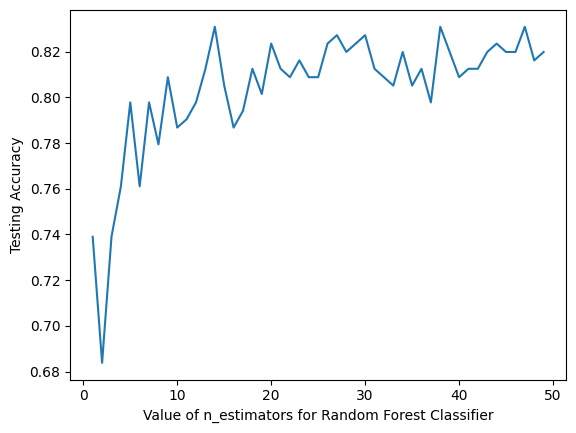

In [45]:
scores =[]
for k in range(1, 50):
    rfc = RandomForestClassifier(n_estimators=k)
    rfc.fit(X_train_rf, y_train_rf)
    y_pred_rf = rfc.predict(X_test_rf)
    scores.append(accuracy_score(y_test_rf, y_pred_rf))

import matplotlib.pyplot as plt
%matplotlib inline

# plot the relationship between K and testing accuracy
# plt.plot(x_axis, y_axis)
plt.plot(range(1, 50), scores)
plt.xlabel('Value of n_estimators for Random Forest Classifier')
plt.ylabel('Testing Accuracy')

In [46]:
random_forest_model = RandomForestClassifier(n_estimators=25, random_state=42)
random_forest_model.fit(X_train_rf, y_train_rf)
y_pred_rf = random_forest_model.predict(X_test_rf)
y_pred_rf

array([1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 1, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int64)

In [47]:
rf_acc_train = random_forest_model.score(X_train_rf, y_train_rf)
rf_acc_test = random_forest_model.score(X_test_rf, y_test_rf)
print(f"Random Forest Accuracy on Training Set: {rf_acc_train:.4f}")
print(f"Random Forest Accuracy on Test Set: {rf_acc_test:.4f}")

Random Forest Accuracy on Training Set: 0.9996
Random Forest Accuracy on Test Set: 0.8162


In [48]:
# Weighted summary metrics for multiclass Random Forest.
rf_precision_weighted = precision_score(y_test_rf, y_pred_rf, average='weighted', zero_division=0)
rf_recall_weighted = recall_score(y_test_rf, y_pred_rf, average='weighted', zero_division=0)
rf_f1_weighted = f1_score(y_test_rf, y_pred_rf, average='weighted', zero_division=0)
print(f"Random Forest Precision (weighted): {rf_precision_weighted:.4f}")
print(f"Random Forest Recall (weighted): {rf_recall_weighted:.4f}")
print(f"Random Forest F1 Score (weighted): {rf_f1_weighted:.4f}")

Random Forest Precision (weighted): 0.8180
Random Forest Recall (weighted): 0.8162
Random Forest F1 Score (weighted): 0.8148


In [49]:
prec_rf, rec_rf, f1_vals_rf, _ = precision_recall_fscore_support(y_test_rf, y_pred_rf, labels=[0, 1, 2], zero_division=0)

class_metrics_rf = {
    0: {'precision': prec_rf[0], 'recall': rec_rf[0], 'f1': f1_vals_rf[0]},
    1: {'precision': prec_rf[1], 'recall': rec_rf[1], 'f1': f1_vals_rf[1]},
    2: {'precision': prec_rf[2], 'recall': rec_rf[2], 'f1': f1_vals_rf[2]},
}
class_metrics_rf

{0: {'precision': 0.5714285714285714, 'recall': 0.3076923076923077, 'f1': 0.4},
 1: {'precision': 0.8873873873873874,
  'recall': 0.8873873873873874,
  'f1': 0.8873873873873874},
 2: {'precision': 0.4883720930232558,
  'recall': 0.5675675675675675,
  'f1': 0.525}}

In [50]:
model_predictions['RF'] = y_pred_rf  # Add RF to the predictions dict (keeps SVM)

print(f"RF Accuracy: {rf_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_rf[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_rf[cls]['recall']:.4f}, "
        f"F1: {class_metrics_rf[cls]['f1']:.4f}"
    )

RF Accuracy: 0.8162
Class 0 -> Precision: 0.5714, Recall: 0.3077, F1: 0.4000
Class 1 -> Precision: 0.8874, Recall: 0.8874, F1: 0.8874
Class 2 -> Precision: 0.4884, Recall: 0.5676, F1: 0.5250


In [51]:
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2]
)

comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

### Random Forest Hyperparameter

In [52]:
# GridSearchCV to find the best hyperparameters for Random Forest
param_grid_rf = {'n_estimators': [100, 200, 300],'max_depth': [None, 10, 20],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],
                 'max_features': ['sqrt', 'log2']}

grid_search_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced_subsample', random_state=42),param_grid_rf,cv=5,scoring='f1_weighted',n_jobs=-1,verbose=1)
grid_search_rf.fit(X_train_rf, y_train_rf)

rf_best_params = grid_search_rf.best_params_
rf_best_score = grid_search_rf.best_score_

print(f"Best Random Forest Parameters: {rf_best_params}")
print(f"Best Random Forest CV F1 (weighted): {rf_best_score:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Random Forest Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Random Forest CV F1 (weighted): 0.9363


In [53]:
random_forest_model_optimal = grid_search_rf.best_estimator_
y_pred_rf_optimal = random_forest_model_optimal.predict(X_test_rf)
y_pred_rf_optimal

array([1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int64)

In [54]:
rf_optimal_acc_train = random_forest_model.score(X_train_rf, y_train_rf)
rf_optimal_acc_test = random_forest_model.score(X_test_rf, y_test_rf)
print(f"Random Forest Accuracy on Training Set: {rf_optimal_acc_train:.4f}")
print(f"Random Forest Accuracy on Test Set: {rf_optimal_acc_test:.4f}")

Random Forest Accuracy on Training Set: 0.9996
Random Forest Accuracy on Test Set: 0.8162


In [55]:
# Weighted summary metrics for multiclass Random Forest.
rf_optimal_precision_weighted = precision_score(y_test_rf, y_pred_rf_optimal, average='weighted', zero_division=0)
rf_optimal_recall_weighted = recall_score(y_test_rf, y_pred_rf_optimal, average='weighted', zero_division=0)
rf_optimal_f1_weighted = f1_score(y_test_rf, y_pred_rf_optimal, average='weighted', zero_division=0)
print(f"Random Forest Precision (weighted): {rf_optimal_precision_weighted:.4f}")
print(f"Random Forest Recall (weighted): {rf_optimal_recall_weighted:.4f}")
print(f"Random Forest F1 Score (weighted): {rf_optimal_f1_weighted:.4f}")

Random Forest Precision (weighted): 0.8282
Random Forest Recall (weighted): 0.8272
Random Forest F1 Score (weighted): 0.8209


In [56]:
prec_rf_optimal, rec_rf_optimal, f1_vals_rf_optimal, _ = precision_recall_fscore_support(y_test_rf, y_pred_rf_optimal, labels=[0, 1, 2], zero_division=0)

class_metrics_rf_optimal = {
    0: {'precision': prec_rf_optimal[0], 'recall': rec_rf_optimal[0], 'f1': f1_vals_rf_optimal[0]},
    1: {'precision': prec_rf_optimal[1], 'recall': rec_rf_optimal[1], 'f1': f1_vals_rf_optimal[1]},
    2: {'precision': prec_rf_optimal[2], 'recall': rec_rf_optimal[2], 'f1': f1_vals_rf_optimal[2]},
}
class_metrics_rf_optimal

{0: {'precision': 0.75,
  'recall': 0.23076923076923078,
  'f1': 0.35294117647058826},
 1: {'precision': 0.8854625550660793,
  'recall': 0.9054054054054054,
  'f1': 0.8953229398663697},
 2: {'precision': 0.5121951219512195,
  'recall': 0.5675675675675675,
  'f1': 0.5384615384615384}}

In [57]:
model_predictions['RF'] = y_pred_rf_optimal  # Add RF to the predictions dict (keeps SVM)

print(f"RF Accuracy: {rf_optimal_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_rf_optimal[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_rf_optimal[cls]['recall']:.4f}, "
        f"F1: {class_metrics_rf_optimal[cls]['f1']:.4f}"
    )

RF Accuracy: 0.8162
Class 0 -> Precision: 0.7500, Recall: 0.2308, F1: 0.3529
Class 1 -> Precision: 0.8855, Recall: 0.9054, F1: 0.8953
Class 2 -> Precision: 0.5122, Recall: 0.5676, F1: 0.5385


In [58]:
optimized_predictions = {'SVM': y_pred_optimal,'RF': y_pred_rf_optimal,}

optimized_comparison_table = build_model_comparison_table(
    y_test,
    optimized_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2],
    y_true_by_model={
        'SVM': globals().get('y_test_svm', y_test),
        'RF': globals().get('y_test_rf', y_test),
        'KNN': globals().get('y_test_knn', y_test),
        'GB': globals().get('y_test_gb', y_test),
        'DT': globals().get('y_test_dt', y_test),
    },
)
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### K Nearest Neighbor 

In [59]:
# Train KNN on the balanced training split while keeping evaluation on the original test split.
X_train_knn, X_test_knn, y_train_knn, y_test_knn = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [60]:
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_train_knn, y_train_knn)
y_pred_knn = KNN_model.predict(X_test_knn)
y_pred_knn

array([1, 1, 0, 1, 0, 0, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 0, 0, 1, 0, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 0, 1, 1, 0, 1, 2,
       1, 2, 1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 2, 0, 2, 1, 1, 0, 2, 1, 1, 0,
       0, 1, 2, 1, 1, 0, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 0, 2,
       2, 1, 2, 0, 2, 0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 2, 2,
       2, 1, 0, 1, 1, 2, 2, 2, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1, 1,
       1, 2, 2, 2, 1, 2, 1, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1,
       2, 2, 2, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2,
       2, 2, 1, 0, 0, 1, 0, 1, 0, 2, 1, 1, 1, 0, 1, 1, 1, 2, 2, 0, 2, 1,
       1, 1, 1, 1, 2, 2, 2, 1, 0, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2,
       0, 0, 1, 1, 1, 2, 2, 1, 1, 2, 0, 2, 2, 1, 0, 0, 1, 1, 1, 0, 1, 2,
       0, 1, 1, 1, 1, 2, 2, 2], dtype=int64)

In [61]:
knn_acc_train = KNN_model.score(X_train_knn, y_train_knn)
knn_acc_test = KNN_model.score(X_test_knn, y_test_knn)
print(f"KNN Accuracy on Training Set: {knn_acc_train:.4f}")
print(f"KNN Accuracy on Test Set: {knn_acc_test:.4f}")

KNN Accuracy on Training Set: 0.9086
KNN Accuracy on Test Set: 0.6360


In [62]:
knn_precision_weighted = precision_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
knn_recall_weighted = recall_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
knn_f1_weighted = f1_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
print(f"KNN Precision (weighted): {knn_precision_weighted:.4f}")
print(f"KNN Recall (weighted): {knn_recall_weighted:.4f}")
print(f"KNN F1 Score (weighted): {knn_f1_weighted:.4f}")

KNN Precision (weighted): 0.8115
KNN Recall (weighted): 0.6360
KNN F1 Score (weighted): 0.6812


In [63]:
prec_knn, rec_knn, f1_vals_knn, _ = precision_recall_fscore_support(y_test_knn, y_pred_knn, labels=[0, 1, 2], zero_division=0)
class_metrics_knn = {
    0: {'precision': prec_knn[0], 'recall': rec_knn[0], 'f1': f1_vals_knn[0]},
    1: {'precision': prec_knn[1], 'recall': rec_knn[1], 'f1': f1_vals_knn[1]},
    2: {'precision': prec_knn[2], 'recall': rec_knn[2], 'f1': f1_vals_knn[2]},
}
class_metrics_knn

{0: {'precision': 0.15384615384615385,
  'recall': 0.46153846153846156,
  'f1': 0.23076923076923078},
 1: {'precision': 0.9251700680272109,
  'recall': 0.6126126126126126,
  'f1': 0.7371273712737128},
 2: {'precision': 0.36046511627906974,
  'recall': 0.8378378378378378,
  'f1': 0.5040650406504065}}

In [64]:
model_predictions['KNN'] = y_pred_knn  # Add KNN to the predictions dict (keeps SVM and RF)
print(f"KNN Accuracy: {knn_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_knn[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_knn[cls]['recall']:.4f}, "
        f"F1: {class_metrics_knn[cls]['f1']:.4f}"
    )

KNN Accuracy: 0.6360
Class 0 -> Precision: 0.1538, Recall: 0.4615, F1: 0.2308
Class 1 -> Precision: 0.9252, Recall: 0.6126, F1: 0.7371
Class 2 -> Precision: 0.3605, Recall: 0.8378, F1: 0.5041


In [65]:
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2]
)

comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')


### KNN Hyperparameter

In [66]:
# GridSearchCV to find the best hyperparameters for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_knn.fit(X_train_knn, y_train_knn)

knn_best_params = grid_search_knn.best_params_
knn_best_score = grid_search_knn.best_score_

print(f"Best KNN Parameters: {knn_best_params}")
print(f"Best KNN CV F1 (weighted): {knn_best_score:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best KNN CV F1 (weighted): 0.8841


In [67]:
KNN_model_optimal = grid_search_knn.best_estimator_
y_pred_knn_optimal = KNN_model_optimal.predict(X_test_knn)
y_pred_knn_optimal

array([1, 1, 1, 1, 0, 0, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 0, 1, 0, 1, 1, 2, 1, 1, 2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2,
       1, 2, 1, 0, 1, 1, 2, 1, 1, 2, 1, 1, 1, 0, 2, 1, 1, 0, 2, 1, 1, 0,
       0, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 0, 2,
       1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2,
       1, 1, 1, 1, 1, 2, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 1, 2, 2, 1, 2, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1,
       1, 1, 2, 1, 1, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 2,
       2, 2, 1, 0, 0, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1, 2, 0, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2,
       0, 0, 1, 1, 1, 2, 2, 0, 2, 2, 0, 2, 2, 1, 0, 1, 2, 1, 1, 0, 1, 1,
       2, 1, 1, 1, 1, 2, 2, 2], dtype=int64)

In [71]:
knn_acc_train_optimal = KNN_model_optimal.score(X_train_knn, y_train_knn)
knn_acc_test_optimal = KNN_model_optimal.score(X_test_knn, y_test_knn)
print(f"KNN Accuracy on Training Set: {knn_acc_train_optimal:.4f}")
print(f"KNN Accuracy on Test Set: {knn_acc_test_optimal:.4f}")

KNN Accuracy on Training Set: 1.0000
KNN Accuracy on Test Set: 0.6985


In [72]:
knn_precision_weighted_optimal = precision_score(y_test_knn, y_pred_knn_optimal, average='weighted', zero_division=0)
knn_recall_weighted_optimal = recall_score(y_test_knn, y_pred_knn_optimal, average='weighted', zero_division=0)
knn_f1_weighted_optimal = f1_score(y_test_knn, y_pred_knn_optimal, average='weighted', zero_division=0)
print(f"KNN Precision (weighted): {knn_precision_weighted_optimal:.4f}")
print(f"KNN Recall (weighted): {knn_recall_weighted_optimal:.4f}")
print(f"KNN F1 Score (weighted): {knn_f1_weighted_optimal:.4f}")

KNN Precision (weighted): 0.8035
KNN Recall (weighted): 0.6985
KNN F1 Score (weighted): 0.7314


In [73]:
prec_knn_optimal, rec_knn_optimal, f1_vals_knn_optimal, _ = precision_recall_fscore_support(y_test_knn, y_pred_knn_optimal, labels=[0, 1, 2], zero_division=0)
class_metrics_knn_optimal = {
    0: {'precision': prec_knn_optimal[0], 'recall': rec_knn_optimal[0], 'f1': f1_vals_knn_optimal[0]},
    1: {'precision': prec_knn_optimal[1], 'recall': rec_knn_optimal[1], 'f1': f1_vals_knn_optimal[1]},
    2: {'precision': prec_knn_optimal[2], 'recall': rec_knn_optimal[2], 'f1': f1_vals_knn_optimal[2]},
}
class_metrics_knn_optimal

{0: {'precision': 0.22580645161290322,
  'recall': 0.5384615384615384,
  'f1': 0.3181818181818182},
 1: {'precision': 0.9075144508670521,
  'recall': 0.7072072072072072,
  'f1': 0.7949367088607595},
 2: {'precision': 0.38235294117647056,
  'recall': 0.7027027027027027,
  'f1': 0.49523809523809526}}

In [74]:
model_predictions['KNN'] = y_pred_knn_optimal  # Add KNN to the predictions dict (keeps SVM and RF)
print(f"KNN Accuracy: {knn_acc_test_optimal:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_knn_optimal[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_knn_optimal[cls]['recall']:.4f}, "
        f"F1: {class_metrics_knn_optimal[cls]['f1']:.4f}"
    )

KNN Accuracy: 0.6985
Class 0 -> Precision: 0.2258, Recall: 0.5385, F1: 0.3182
Class 1 -> Precision: 0.9075, Recall: 0.7072, F1: 0.7949
Class 2 -> Precision: 0.3824, Recall: 0.7027, F1: 0.4952


In [75]:
optimized_predictions = {'SVM': y_pred_optimal,'RF': y_pred_rf_optimal,'KNN': y_pred_knn_optimal}

optimized_comparison_table = build_model_comparison_table(
    y_test,
    optimized_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2],
    y_true_by_model={
        'SVM': globals().get('y_test_svm', y_test),
        'RF': globals().get('y_test_rf', y_test),
        'KNN': globals().get('y_test_knn', y_test),
        'GB': globals().get('y_test_gb', y_test),
        'DT': globals().get('y_test_dt', y_test),
    },
)
optimized_comparison_table.style.format('{:.2f}', na_rep='').set_caption('Optimized Model Comparison by Class')

### Gradient Boosting 

In [83]:
# Train GB on the balanced training split while keeping evaluation on the original test split.
X_train_gb, X_test_gb, y_train_gb, y_test_gb = X_train_balanced, X_test_scaled, y_train_balanced, y_test

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_gb, y_train_gb)
y_pred_gb = gb_model.predict(X_test_gb)
y_pred_gb


array([1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 0, 1, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 1, 2, 1, 0, 1, 2,
       1, 2, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2,
       2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1,
       2, 1, 2, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 1,
       1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 2], dtype=int64)

In [ ]:
gb_acc_train = gb_model.score(X_train_gb, y_train_gb)
gb_acc_test = gb_model.score(X_test_gb, y_test_gb)
print(f"Gradient Boosting Accuracy on Training Set: {gb_acc_train:.4f}")
print(f"Gradient Boosting Accuracy on Test Set: {gb_acc_test:.4f}")


Gradient Boosting Accuracy on Training Set: 0.9524
Gradient Boosting Accuracy on Test Set: 0.8051


In [ ]:
gb_precision_weighted = precision_score(y_test_gb, y_pred_gb, average='weighted', zero_division=0)
gb_recall_weighted = recall_score(y_test_gb, y_pred_gb, average='weighted', zero_division=0)
gb_f1_weighted = f1_score(y_test_gb, y_pred_gb, average='weighted', zero_division=0)
print(f"Gradient Boosting Precision (weighted): {gb_precision_weighted:.4f}")
print(f"Gradient Boosting Recall (weighted): {gb_recall_weighted:.4f}")
print(f"Gradient Boosting F1 Score (weighted): {gb_f1_weighted:.4f}")


Gradient Boosting Precision (weighted): 0.8279
Gradient Boosting Recall (weighted): 0.8051
Gradient Boosting F1 Score (weighted): 0.8137


In [ ]:
prec_gb, rec_gb, f1_vals_gb, _ = precision_recall_fscore_support(y_test_gb, y_pred_gb, labels=[0, 1, 2], zero_division=0)
class_metrics_gb = {
    0: {'precision': prec_gb[0], 'recall': rec_gb[0], 'f1': f1_vals_gb[0]},
    1: {'precision': prec_gb[1], 'recall': rec_gb[1], 'f1': f1_vals_gb[1]},
    2: {'precision': prec_gb[2], 'recall': rec_gb[2], 'f1': f1_vals_gb[2]},
}
class_metrics_gb


{0: {'precision': 0.3333333333333333,
  'recall': 0.38461538461538464,
  'f1': 0.35714285714285715},
 1: {'precision': 0.9082125603864735,
  'recall': 0.8468468468468469,
  'f1': 0.8764568764568764},
 2: {'precision': 0.52,
  'recall': 0.7027027027027027,
  'f1': 0.5977011494252874}}

In [80]:
model_predictions['GB'] = y_pred_gb  # Add GB to the predictions dict (keeps SVM, RF, KNN)
print(f"GB Accuracy: {gb_acc_test:.4f}")
for cls in [0, 1, 2]:
    print(
        f"Class {cls} -> Precision: {class_metrics_gb[cls]['precision']:.4f}, "
        f"Recall: {class_metrics_gb[cls]['recall']:.4f}, "
        f"F1: {class_metrics_gb[cls]['f1']:.4f}"
    )

GB Accuracy: 0.8051
Class 0 -> Precision: 0.3333, Recall: 0.3846, F1: 0.3571
Class 1 -> Precision: 0.9082, Recall: 0.8468, F1: 0.8765
Class 2 -> Precision: 0.5200, Recall: 0.7027, F1: 0.5977


In [81]:
comparison_table = build_model_comparison_table(
    y_test,
    model_predictions,
    model_order=['SVM', 'RF', 'KNN', 'GB', 'DT'],
    class_labels=[0, 1, 2]
)
comparison_table.style.format('{:.2f}', na_rep='').set_caption('Model Comparison by Class')

### Gradient Boosting Hyperparameter

In [ ]:
# GridSearchCV to find the best hyperparameters for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search_gb.fit(X_train_gb, y_train_gb)
gb_best_params = grid_search_gb.best_params_
gb_best_score = grid_search_gb.best_score_

print(f"Best Gradient Boosting Parameters: {gb_best_params}")
print(f"Best Gradient Boosting CV F1 (weighted): {gb_best_score:.4f}")


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Gradient Boosting Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Gradient Boosting CV F1 (weighted): 0.9449


In [ ]:
gb_model_optimal = grid_search_gb.best_estimator_
y_pred_gb_optimal = gb_model_optimal.predict(X_test_gb)
y_pred_gb_optimal


### Confusion Matrices

Keep all confusion-matrix helper and plotting code together at the end of the notebook.

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix_single(y_true, y_pred, model_name='Model', class_labels=None, title_prefix='Confusion Matrix'):
    y_true = np.asarray(y_true)
    if class_labels is None:
        class_labels = sorted(np.unique(y_true))
    else:
        class_labels = list(class_labels)

    y_pred = _coerce_to_class_labels(y_pred, class_labels)
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(ax=ax, colorbar=False)
    ax.set_title(f'{title_prefix}: {model_name}')
    plt.tight_layout()
    plt.show()

# Run one model at a time here after you finish each model.
# Example:
# plot_confusion_matrix_single(y_test, y_pred_svm, model_name='SVM', class_labels=[0, 1, 2])

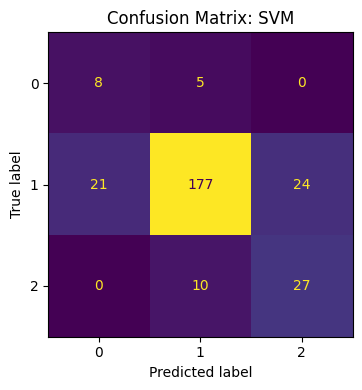

In [69]:
plot_confusion_matrix_single(y_test, y_pred_svm, model_name='SVM', class_labels=[0, 1, 2])

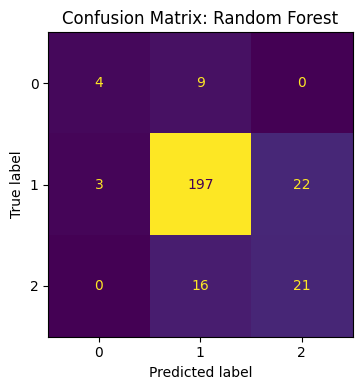

In [70]:
plot_confusion_matrix_single(y_test_rf, y_pred_rf, model_name='Random Forest', class_labels=[0, 1, 2])